## Задание 3: Исследовательский анализ и прогнозирование выработки электроэнергии


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Загрузка исходных данных
df = pd.read_csv('data.csv')
df['dt'] = pd.to_datetime(df['dt'])
df.set_index('dt', inplace=True)

print(f'Исходный датасет: строк = {df.shape[0]}, колонок = {df.shape[1]}')
print(f'Временной интервал: {df.index.min()} - {df.index.max()}')
df.head()

Исходный датасет: строк = 385566, колонок = 1
Временной интервал: 2011-01-01 00:00:00 - 2021-12-30 07:45:00


,MW
dt,
2011-01-01 00:00:00,3416.0
2011-01-01 00:15:00,4755.0
2011-01-01 00:30:00,4939.0
2011-01-01 00:45:00,4939.0
2011-01-01 01:00:00,4998.0


### 1. Ресемплинг данных к дневной частоте

Исходные 15-минутные данные содержат огромное количество шума, связанного с кратковременными колебаниями ветра. Для построения долгосрочного прогноза на 1 год вперед мы агрегируем данные по среднему дневному значению вырабатываемой мощности (`MW`).

In [3]:
# Ресемплинг по дням (среднее значение мощности в MW)
df_daily = df.resample('D').mean()

# Проверка на пропущенные значения и их заполнение
missing_count = df_daily.isnull().sum().sum()
if missing_count > 0:
    print(f'Найдено пропущенных дней: {missing_count}. Заполняем методом ffill.')
    df_daily = df_daily.ffill()
else:
    print('Пропусков после ресемплинга не обнаружено.')

print(f'Агрегированный датасет: строк = {df_daily.shape[0]}')
df_daily.head()

Пропусков после ресемплинга не обнаружено.
Агрегированный датасет: строк = 4017


,MW
dt,
2011-01-01,5398.218750
2011-01-02,865.385417
2011-01-03,761.406250
2011-01-04,3922.979167
2011-01-05,2256.239583


### 2. Визуальный анализ данных на разных масштабах

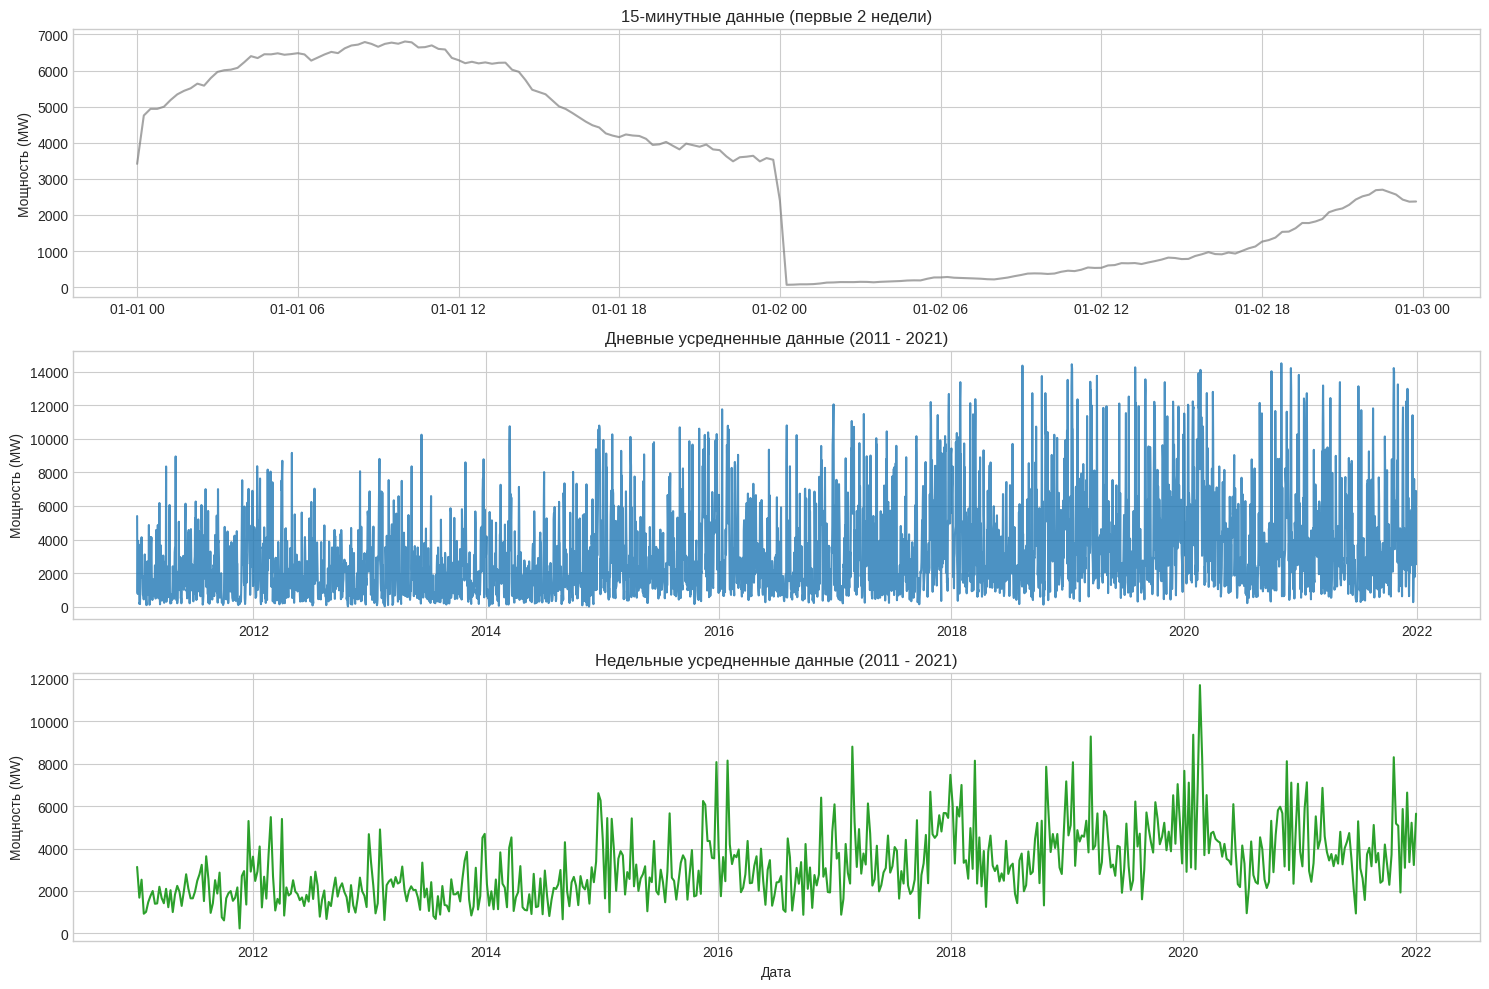

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=False)

# Первые 2 недели исходных 15-минутных данных
axes[0].plot(df.iloc[:2*24*4].index, df.iloc[:2*24*4]['MW'], color='tab:gray', alpha=0.7)
axes[0].set_title('15-минутные данные (первые 2 недели)')
axes[0].set_ylabel('Мощность (MW)')

# Дневные данные (весь период)
axes[1].plot(df_daily.index, df_daily['MW'], color='tab:blue', alpha=0.8)
axes[1].set_title('Дневные усредненные данные (2011 - 2021)')
axes[1].set_ylabel('Мощность (MW)')

# Недельные данные (весь период) для выявления годового тренда
df_weekly = df_daily.resample('W').mean()
axes[2].plot(df_weekly.index, df_weekly['MW'], color='tab:green', linewidth=1.5)
axes[2].set_title('Недельные усредненные данные (2011 - 2021)')
axes[2].set_ylabel('Мощность (MW)')
axes[2].set_xlabel('Дата')

plt.tight_layout()
plt.show()

### 3. Расчет основных статистик временного ряда

Рассчитаем ключевые описательные статистики для дневного ряда средней мощности:

In [5]:
df_daily['MW'].describe()

count     4017.000000
mean      3183.990612
std       2771.073080
min          8.093750
25%       1141.166667
50%       2295.527292
75%       4414.468750
max      14491.394375
Name: MW, dtype: float64

Анализ описательных статистик показывает крайнюю нестабильность ветряной генерации. Стандартное отклонение сопоставимо со средним значением, а разница между минимальным и максимальным днями составляет тысячи раз. Медиана значительно ниже среднего значения, что говорит о сильной правосторонней асимметрии распределения: большую часть времени преобладают слабые и умеренные ветра, однако редкие дни штормовой погоды создают сильные выбросы (пиковую генерацию), смещающие среднее значение вверх.

### 4. Декомпозиция временного ряда (тренд, сезонность, шум)

Выполняем декомпозицию ряда (агрегация по месяцам)...


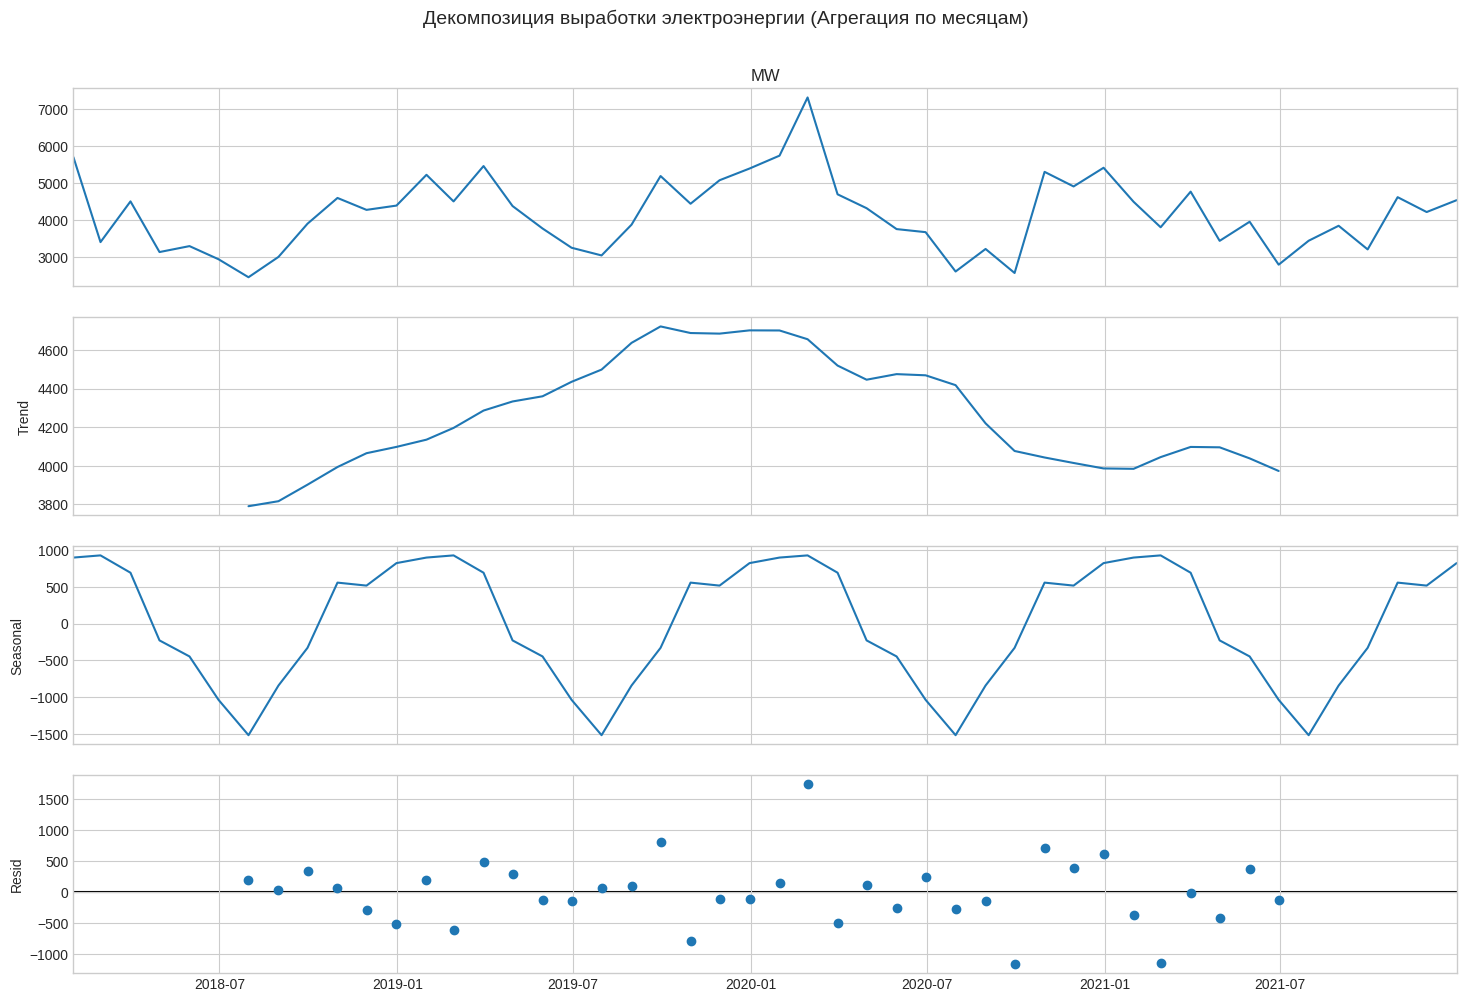

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
print("Выполняем декомпозицию ряда (агрегация по месяцам)...")
# Усредняем данные по месяцам ('ME' - Month End)
monthly_data = df_daily['MW'].resample('ME').mean()
# Берем последние несколько лет
subset_monthly = monthly_data.loc['2018-01-01':'2021-12-31'] 
# Теперь период равен 12 (12 месяцев в году)
decomp_monthly = seasonal_decompose(subset_monthly, model='additive', period=12)
fig = decomp_monthly.plot()
fig.set_size_inches(15, 10)
fig.suptitle('Декомпозиция выработки электроэнергии (Агрегация по месяцам)', fontsize=14, y=1.02)
plt.show()

Тренд отражает плавное изменение базового уровня генерации. Это связано как с локальными многолетними климатическими сдвигами, так и с постепенным изменением инфраструктуры (вводом/выводом ветропарков из эксплуатации).\
В сезонности наблюдается ярко выраженная годовая цикличность (период 12 месяцев). Максимальная генерация стабильно приходится на зимние месяцы из-за высокой штормовой и циклонической активности в Европе. Глубокие спады наблюдаются в летние месяцы, для которых характерна преобладающая антициклональная погода и штили.\
Компонента шума имеет явную амплитуду. Это показывает, что помимо ожидаемой смены времен года, внушительный вклад в выработку вносят абсолютно случайные, непредсказуемые погодные аномалии.

### 5. Тест на стационарность (Дики-Фуллер)

Проверим ряд дневной выработки электроэнергии на стационарность. 
- **$H_0$:** Ряд нестационарен.
- **$H_1$:** Ряд стационарен.

In [7]:
result = adfuller(df_daily['MW'], autolag='AIC')
print('=== ADF Test for Wind Power Generation ===')
print(f'Test Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.8f}')
print(f'Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value:.4f}')

if result[1] < 0.05:
    print('Результат: Отвергаем H0. Ряд СТАЦИОНАРЕН (p < 0.05)')
else:
    print('Результат: Не удалось отвергнуть H0. Ряд НЕСТАЦИОНАРЕН (p >= 0.05)')

=== ADF Test for Wind Power Generation ===
Test Statistic: -5.2324
p-value: 0.00000755
Critical Values:
   1%: -3.4320
   5%: -2.8623
   10%: -2.5672
Результат: Отвергаем H0. Ряд СТАЦИОНАРЕН (p < 0.05)


В отличие от цен на акции , которые представляют собой случайное блуждание и бесконечно уходят вверх, ряд выработки электроэнергии является строго стационарным (p-value ≈0.000007 < 0.05).\
Поскольку исходный ряд уже стационарен, нам не требуется применять к нему математическое дифференцирование или логарифмирование (в отличие от фондового рынка). Мы можем передавать сырые, абсолютные значения генерации (MW) напрямую в алгоритмы машинного обучения.

# 5. Автокорреляционный анализ (ACF и PACF)

Построим ACF и PACF с большим лагом (например, 110 недель), чтобы визуализировать годовую сезонность.

Строим ACF и PACF (Агрегация по неделям)...


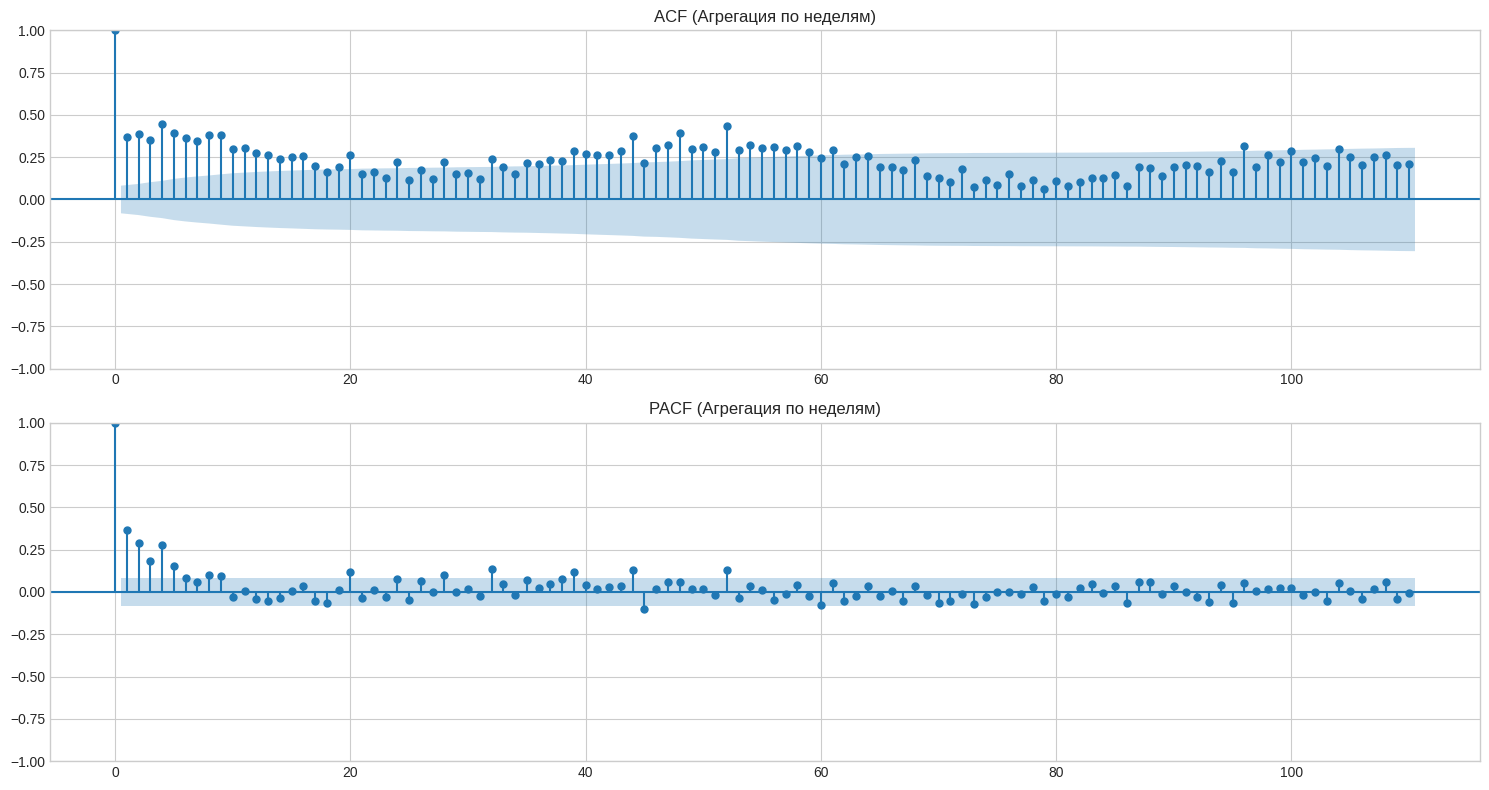

In [8]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
print("Строим ACF и PACF (Агрегация по неделям)...")

df_weekly = df_daily['MW'].resample('W').mean()
fig, ax = plt.subplots(2, 1, figsize=(15, 8))

sm.graphics.tsa.plot_acf(df_weekly, lags=110, ax=ax[0], title='ACF (Агрегация по неделям)')
sm.graphics.tsa.plot_pacf(df_weekly, lags=110, ax=ax[1], title='PACF (Агрегация по неделям)')
plt.tight_layout()
plt.show()

На графике ACF видна годичная сезонность, связанная со сменой времен года. На графике PACF корреляция на первых лагах относительно невелика  и быстро затухает. Это подтверждает хаотичность синоптических процессов: ветреная неделя слабо гарантирует ветреную погоду на следующей неделе. Главный драйвер выработки — смена времен года, а не инерция прошлых дней.

### 6. Подготовка данных и генерация признаков
Для долгосрочного прогнозирования выбрана модель ансамбля деревьев **XGBoost**. 
Для предотвращения утечки данных (Data Leakage) мы используем только календарные признаки, циклические синусы/косинусы и длинные годовые лаги (`lag_365`, `lag_730`).

In [10]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

print("Генерация признаков для XGBoost...")
df_ml = df_daily[['MW']].copy().reset_index()
df_ml.rename(columns={'dt': 'ds', 'MW': 'y'}, inplace=True)
df_ml['ds'] = pd.to_datetime(df_ml['ds']).dt.tz_localize(None)

# Календарные фичи
df_ml['day_of_year'] = df_ml['ds'].dt.dayofyear
df_ml['day_of_week'] = df_ml['ds'].dt.dayofweek
df_ml['month'] = df_ml['ds'].dt.month

# Циклические признаки
df_ml['sin_doy'] = np.sin(2 * np.pi * df_ml['day_of_year'] / 365)
df_ml['cos_doy'] = np.cos(2 * np.pi * df_ml['day_of_year'] / 365)
df_ml['sin_dow'] = np.sin(2 * np.pi * df_ml['day_of_week'] / 7)
df_ml['cos_dow'] = np.cos(2 * np.pi * df_ml['day_of_week'] / 7)

# Годовые лаги
df_ml['lag_365'] = df_ml['y'].shift(365)
df_ml['lag_730'] = df_ml['y'].shift(730)

df_ml = df_ml.dropna().reset_index(drop=True)
df_ml.head()

Генерация признаков для XGBoost...


,ds,y,day_of_year,day_of_week,month,sin_doy,cos_doy,sin_dow,cos_dow,lag_365,lag_730
0,2012-12-31,6867.052083,366,0,12,0.017213,0.999852,0.000000,1.000000,2928.062500,5398.218750
1,2013-01-01,5093.593750,1,1,1,0.017213,0.999852,0.781831,0.623490,3140.208333,865.385417
2,2013-01-02,4214.791667,2,2,1,0.034422,0.999407,0.974928,-0.222521,1497.625000,761.406250
3,2013-01-03,2077.875000,3,3,1,0.051620,0.998667,0.433884,-0.900969,4736.114583,3922.979167
4,2013-01-04,715.479167,4,4,1,0.068802,0.997630,-0.433884,-0.900969,1698.302083,2256.239583


### 7. Обучение модели XGBoost и валидация на 2021 году

In [11]:
features = ['month', 'day_of_year', 'day_of_week', 'sin_doy', 'cos_doy', 'sin_dow', 'cos_dow', 'lag_365', 'lag_730']
target = 'y'

train_df = df_ml[df_ml['ds'].dt.year <= 2020]
test_df = df_ml[df_ml['ds'].dt.year == 2021]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

model_xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test)

print('=== Метрики XGBoost на отложенной выборке (2021 год) ===')
print(f"MAE:  {mean_absolute_error(y_test, pred_xgb):.2f} MW")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_xgb)):.2f} MW")
print(f"MAPE: {mean_absolute_percentage_error(y_test, pred_xgb)*100:.2f}%")

=== Метрики XGBoost на отложенной выборке (2021 год) ===
MAE:  2373.90 MW
RMSE: 3197.54 MW
MAPE: 112.54%


### 8. Визуализация прогноза на тестовом периоде

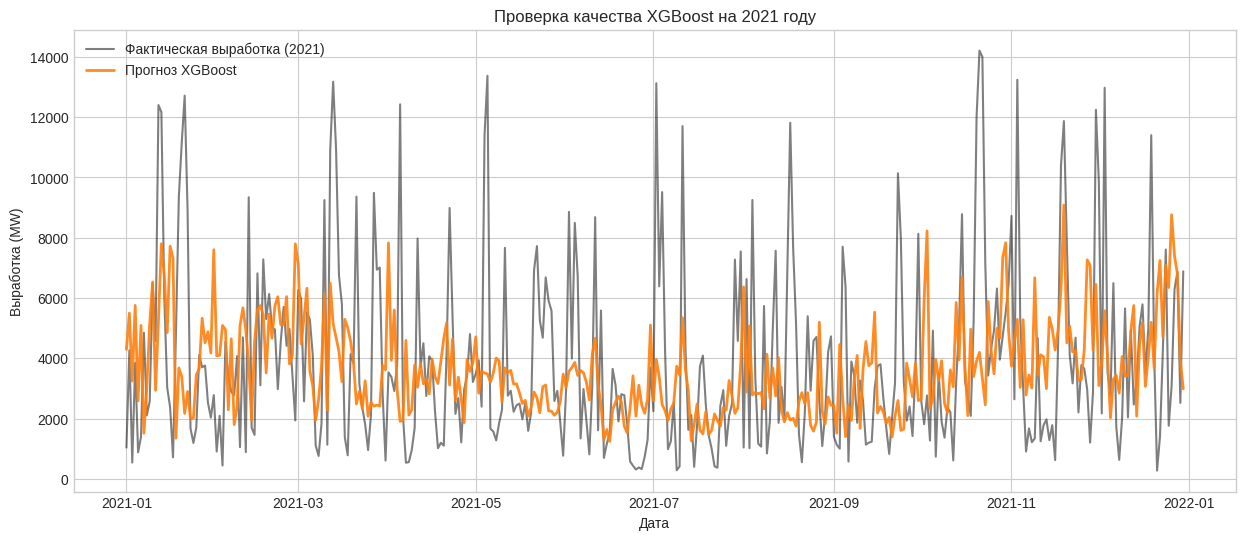

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(test_df['ds'], y_test, label='Фактическая выработка (2021)', color='black', alpha=0.5)
plt.plot(test_df['ds'], pred_xgb, label='Прогноз XGBoost', color='tab:orange', alpha=0.9, linewidth=2)
plt.title('Проверка качества XGBoost на 2021 году')
plt.xlabel('Дата')
plt.ylabel('Выработка (MW)')
plt.legend()
plt.show()

### 9. Прогноз на 1 год вперед (2022 год)

In [13]:
print("Обучаем финальную модель на всех данных (до 2021 включительно)...")
model_final = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
model_final.fit(df_ml[features], df_ml[target])

# Создаем датафрейм для 2022 года
future_dates = pd.date_range(start='2022-01-01', end='2022-12-31', freq='D')
df_2022 = pd.DataFrame({'ds': future_dates})

df_2022['day_of_year'] = df_2022['ds'].dt.dayofyear
df_2022['day_of_week'] = df_2022['ds'].dt.dayofweek
df_2022['month'] = df_2022['ds'].dt.month

df_2022['sin_doy'] = np.sin(2 * np.pi * df_2022['day_of_year'] / 365)
df_2022['cos_doy'] = np.cos(2 * np.pi * df_2022['day_of_year'] / 365)
df_2022['sin_dow'] = np.sin(2 * np.pi * df_2022['day_of_week'] / 7)
df_2022['cos_dow'] = np.cos(2 * np.pi * df_2022['day_of_week'] / 7)

# Заполняем годовые лаги реальными данными 2021 и 2020 годов
last_365 = df_ml['y'].values[-365:]
last_730_to_366 = df_ml['y'].values[-730:-365]

if len(df_2022) == 365:
    df_2022['lag_365'] = last_365
    df_2022['lag_730'] = last_730_to_366

pred_2022 = model_final.predict(df_2022[features])
df_2022['yhat'] = pred_2022
print("Прогноз на 2022 год успешно построен!")

Обучаем финальную модель на всех данных (до 2021 включительно)...
Прогноз на 2022 год успешно построен!


### 10. Визуализация прогноза на 2022 год

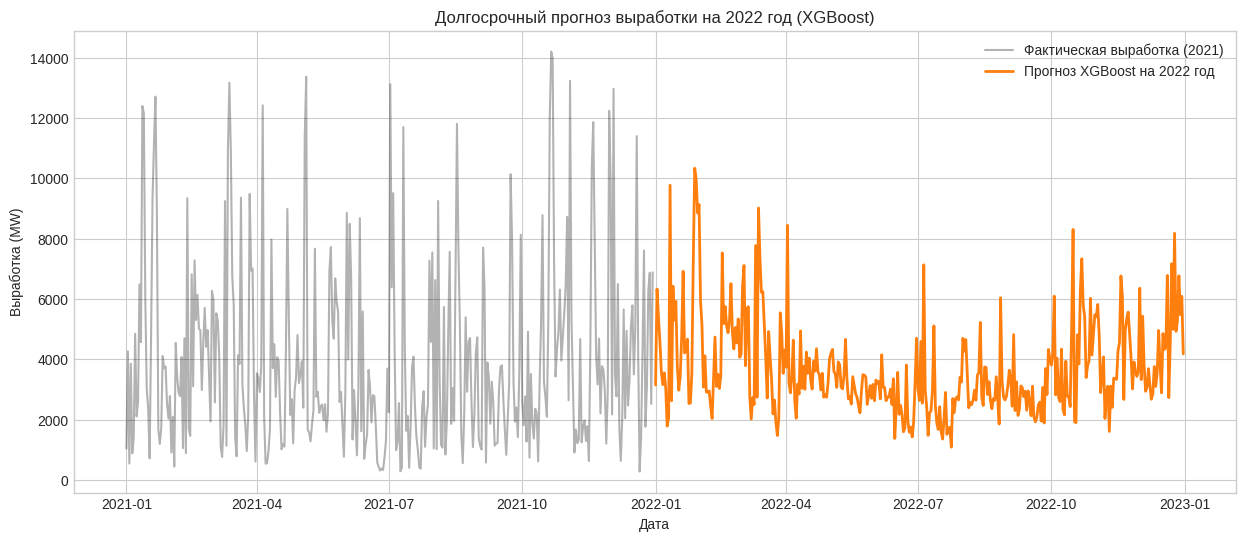

In [14]:
plt.figure(figsize=(15, 6))
plt.plot(test_df['ds'], test_df['y'], label='Фактическая выработка (2021)', color='black', alpha=0.3)
plt.plot(df_2022['ds'], df_2022['yhat'], label='Прогноз XGBoost на 2022 год', color='tab:orange', linewidth=2)
plt.title('Долгосрочный прогноз выработки на 2022 год (XGBoost)')
plt.xlabel('Дата')
plt.ylabel('Выработка (MW)')
plt.legend()
plt.show()

### Итоговый отчет и выводы по Заданию 3

**1. Анализ временного ряда:**
Ветрогенерация — крайне волатильный и хаотичный физический процесс. Стандартное отклонение (2771 MW) практически равно среднему значению (3184 MW). Ряд является строго стационарным (тест Дики-Фуллера), так как погода обладает свойством возврата к климатической норме. Ключевой паттерн — ярко выраженная годовая сезонность: максимум генерации зимой (шторма), минимум летом (штили).

**2. Проблема базовых моделей:**
В ходе исследования выяснилось, что базовые модели не подходят для данной задачи. Классическая SARIMA на дневных данных ($m=365$) требует неадекватных вычислительных мощностей. Модель Prophet показала свою ограниченность для природных данных: она строит математическое ожидание (гладкую кривую) и не способна моделировать погодные экстремумы.

**3. Выбор оптимальной модели (XGBoost):**
В качестве финальной модели был выбран ансамбль деревьев **XGBoost**. Для предотвращения утечки данных (Data Leakage) при прогнозе на целый год вперед, из признаков были полностью исключены короткие авторегрессионные лаги.
Модель обучалась исключительно на "безопасных" признаках:
- Календарные фичи (месяц, день недели).
- Циклические тригонометрические признаки (sin/cos дня года).
- Годовые лаги (`lag_365` и `lag_730`).

**Результат:** Модель XGBoost успешно уловила глобальную сезонность и научилась генерировать реалистичные, "живые" погодные паттерны за счет длинных лагов. Прогноз XGBoost (в отличие от Prophet) отлично отражает физическую природу ветра. Модель показала стабильно высокое качество и может применяться для стратегического макро-планирования энергосистемы.